In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/psfc.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/t2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/SO2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/NMVOC_finn.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/bio.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/rain.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/u10.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/swdown.npy
/kaggle/input/competitions/anrf-aise-hack-pha

In [2]:
# ==========================================
# IMPORTS
# ==========================================

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import os

import torch

import torch.nn as nn

import torch.optim as optim

import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr

from skimage.metrics import (
    structural_similarity as ssim
)

In [3]:
# ==========================================
# DATASET PATH
# ==========================================

base_path = "/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/raw"

In [4]:
# ==========================================
# MONTHS
# ==========================================

train_months = [
    "APRIL_16",
    "JULY_16",
    "OCT_16"
]

val_month = "DEC_16"

# ==========================================
# VARIABLES
# ==========================================

variables = [
    'PM25',
    'NOx',
    'SO2',
    'NH3',
    't2',
    'q2',
    'u10',
    'v10',
    'rain',
    'swdown',
    'pblh',
    'psfc'
]

In [5]:
# ==========================================
# LOAD DATA
# ==========================================

all_months_data = {}

all_required_months = (
    train_months +
    [val_month]
)

for month in all_required_months:
    
    month_path = os.path.join(
        base_path,
        month
    )
    
    month_data = []
    
    print(f"\nLoading {month}...")
    
    for var in variables:
        
        file_path = os.path.join(
            month_path,
            f"{var}.npy"
        )
        
        arr = np.load(file_path)
        
        print(
            f"{var}: {arr.shape}"
        )
        
        month_data.append(arr)
    
    all_months_data[month] = month_data


Loading APRIL_16...
PM25: (715, 140, 124)
NOx: (715, 140, 124)
SO2: (715, 140, 124)
NH3: (715, 140, 124)
t2: (715, 140, 124)
q2: (715, 140, 124)
u10: (715, 140, 124)
v10: (715, 140, 124)
rain: (715, 140, 124)
swdown: (715, 140, 124)
pblh: (715, 140, 124)
psfc: (715, 140, 124)

Loading JULY_16...
PM25: (739, 140, 124)
NOx: (739, 140, 124)
SO2: (739, 140, 124)
NH3: (739, 140, 124)
t2: (739, 140, 124)
q2: (739, 140, 124)
u10: (739, 140, 124)
v10: (739, 140, 124)
rain: (739, 140, 124)
swdown: (739, 140, 124)
pblh: (739, 140, 124)
psfc: (739, 140, 124)

Loading OCT_16...
PM25: (739, 140, 124)
NOx: (739, 140, 124)
SO2: (739, 140, 124)
NH3: (739, 140, 124)
t2: (739, 140, 124)
q2: (739, 140, 124)
u10: (739, 140, 124)
v10: (739, 140, 124)
rain: (739, 140, 124)
swdown: (739, 140, 124)
pblh: (739, 140, 124)
psfc: (739, 140, 124)

Loading DEC_16...
PM25: (739, 140, 124)
NOx: (739, 140, 124)
SO2: (739, 140, 124)
NH3: (739, 140, 124)
t2: (739, 140, 124)
q2: (739, 140, 124)
u10: (739, 140, 124)
v10:

In [6]:
# ==========================================
# STACK CHANNELS
# ==========================================

processed_months = {}

for month in all_required_months:
    
    print(f"\nProcessing {month}...")
    
    channel_data = []
    
    for i, var in enumerate(variables):
        
        arr = all_months_data[month][i]
        
        channel_data.append(arr)
    
    stacked = np.stack(
        channel_data,
        axis=1
    )
    
    processed_months[month] = stacked
    
    print(
        "Final Shape:",
        stacked.shape
    )


Processing APRIL_16...
Final Shape: (715, 12, 140, 124)

Processing JULY_16...
Final Shape: (739, 12, 140, 124)

Processing OCT_16...
Final Shape: (739, 12, 140, 124)

Processing DEC_16...
Final Shape: (739, 12, 140, 124)


In [7]:
# ==========================================
# TRAIN DATASET
# ==========================================

train_data = np.concatenate(
    [
        processed_months[m]
        for m in train_months
    ],
    axis=0
)

# ==========================================
# VALIDATION DATASET
# ==========================================

val_data = processed_months[
    val_month
]

print(
    "Train Shape:",
    train_data.shape
)

print(
    "Validation Shape:",
    val_data.shape
)

Train Shape: (2193, 12, 140, 124)
Validation Shape: (739, 12, 140, 124)


In [8]:
# ==========================================
# CHANNEL-WISE NORMALIZATION
# ==========================================

normalized_train = train_data.copy()

normalized_val = val_data.copy()

channel_mins = []

channel_maxs = []

for ch in range(
    train_data.shape[1]
):
    
    # ======================
    # TRAIN STATS ONLY
    # ======================
    
    ch_min = train_data[:, ch].min()
    
    ch_max = train_data[:, ch].max()
    
    channel_mins.append(ch_min)
    
    channel_maxs.append(ch_max)
    
    # ======================
    # NORMALIZE TRAIN
    # ======================
    
    normalized_train[:, ch] = (
        (train_data[:, ch] - ch_min)
        /
        (ch_max - ch_min + 1e-8)
    )
    
    # ======================
    # NORMALIZE VALIDATION
    # ======================
    
    normalized_val[:, ch] = (
        (val_data[:, ch] - ch_min)
        /
        (ch_max - ch_min + 1e-8)
    )
    
    print(f"\nChannel {ch}")
    
    print("Train Min:", ch_min)
    
    print("Train Max:", ch_max)


Channel 0
Train Min: 0.0
Train Max: 1.4269124885910763e-07

Channel 1
Train Min: 0.0
Train Max: 7.977064445068625e-08

Channel 2
Train Min: 0.0
Train Max: 4.257750712618741e-08

Channel 3
Train Min: 0.0
Train Max: 2.0868043112887928e-08

Channel 4
Train Min: 233.86717224121094
Train Max: 322.6777038574219

Channel 5
Train Min: 0.0
Train Max: 0.037895362824201584

Channel 6
Train Min: -17.27123260498047
Train Max: 22.803133010864258

Channel 7
Train Min: -17.91163444519043
Train Max: 24.005958557128906

Channel 8
Train Min: 0.0
Train Max: 397.03558349609375

Channel 9
Train Min: 0.0
Train Max: 1287.9805908203125

Channel 10
Train Min: 56.20703125
Train Max: 6064.95654296875

Channel 11
Train Min: 48425.32421875
Train Max: 101822.546875


In [9]:
# ==========================================
# NON-OVERLAPPING SEQUENCES
# ==========================================

sequence_length = 12

step_size = 12

# ==========================================
# TRAIN SEQUENCES
# ==========================================

X_train = []

y_train = []

for i in range(
    0,
    len(normalized_train)
    - sequence_length,
    step_size
):
    
    # INPUT
    
    input_seq = normalized_train[
        i:i+sequence_length
    ]
    
    # TARGET
    
    target = normalized_train[
        i+sequence_length,
        0
    ]
    
    X_train.append(input_seq)
    
    y_train.append(target)

# ==========================================
# VALIDATION SEQUENCES
# ==========================================

X_val = []

y_val = []

for i in range(
    0,
    len(normalized_val)
    - sequence_length,
    step_size
):
    
    input_seq = normalized_val[
        i:i+sequence_length
    ]
    
    target = normalized_val[
        i+sequence_length,
        0
    ]
    
    X_val.append(input_seq)
    
    y_val.append(target)

# ==========================================
# NUMPY CONVERSION
# ==========================================

X_train = np.array(X_train)

y_train = np.array(y_train)

X_val = np.array(X_val)

y_val = np.array(y_val)

# ==========================================
# SHAPES
# ==========================================

print("X_train:", X_train.shape)

print("y_train:", y_train.shape)

print("X_val:", X_val.shape)

print("y_val:", y_val.shape)

X_train: (182, 12, 12, 140, 124)
y_train: (182, 140, 124)
X_val: (61, 12, 12, 140, 124)
y_val: (61, 140, 124)


In [10]:
# ==========================================
# CUSTOM DATASET
# ==========================================

class PollutionDataset(Dataset):
    
    def __init__(
        self,
        X,
        y
    ):
        
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )
        
        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )
    
    def __len__(self):
        
        return len(self.X)
    
    def __getitem__(
        self,
        idx
    ):
        
        return (
            self.X[idx],
            self.y[idx]
        )

# ==========================================
# DATASETS
# ==========================================

train_dataset = PollutionDataset(
    X_train,
    y_train
)

val_dataset = PollutionDataset(
    X_val,
    y_val
)

# ==========================================
# DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

# ==========================================
# PRINT INFO
# ==========================================

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 91
Validation batches: 31


In [11]:
# ==========================================
# DEVICE
# ==========================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

# ==========================================
# SPECTRAL CONVOLUTION
# ==========================================

class SpectralConv2d(nn.Module):
    
    def __init__(
        self,
        in_channels,
        out_channels,
        modes1,
        modes2
    ):
        
        super().__init__()
        
        self.in_channels = in_channels
        
        self.out_channels = out_channels
        
        self.modes1 = modes1
        
        self.modes2 = modes2
        
        self.scale = (
            1 /
            (in_channels * out_channels)
        )
        
        self.weights_real = nn.Parameter(
            self.scale *
            torch.rand(
                in_channels,
                out_channels,
                modes1,
                modes2
            )
        )
        
        self.weights_imag = nn.Parameter(
            self.scale *
            torch.rand(
                in_channels,
                out_channels,
                modes1,
                modes2
            )
        )
    
    def compl_mul2d(
        self,
        input,
        weights
    ):
        
        return torch.einsum(
            "bixy,ioxy->boxy",
            input,
            weights
        )
    
    def forward(
        self,
        x
    ):
        
        batchsize = x.shape[0]
        
        # FFT
        
        x_ft = torch.fft.rfft2(x)
        
        # OUTPUT
        
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1)//2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )
        
        # COMPLEX WEIGHTS
        
        weights = torch.complex(
            self.weights_real,
            self.weights_imag
        )
        
        out_ft[
            :,
            :,
            :self.modes1,
            :self.modes2
        ] = self.compl_mul2d(
            x_ft[
                :,
                :,
                :self.modes1,
                :self.modes2
            ],
            weights
        )
        
        # INVERSE FFT
        
        x = torch.fft.irfft2(
            out_ft,
            s=(x.size(-2), x.size(-1))
        )
        
        return x

# ==========================================
# FNO BLOCK
# ==========================================

class FNOBlock(nn.Module):
    
    def __init__(
        self,
        width,
        modes1,
        modes2
    ):
        
        super().__init__()
        
        self.spectral_conv = SpectralConv2d(
            width,
            width,
            modes1,
            modes2
        )
        
        self.conv = nn.Conv2d(
            width,
            width,
            kernel_size=1
        )
        
        self.activation = nn.GELU()
    
    def forward(
        self,
        x
    ):
        
        spectral = self.spectral_conv(x)
        
        local = self.conv(x)
        
        x = spectral + local
        
        x = self.activation(x)
        
        return x

Using device: cuda


In [20]:
# ==========================================
# TEMPORAL ATTENTION
# ==========================================

class TemporalAttention(nn.Module):
    
    def __init__(
        self,
        time_steps
    ):
        
        super().__init__()
        
        self.time_steps = time_steps
    
    def forward(
        self,
        x
    ):
        
        # x:
        # [B, T, C, H, W]
        
        B, T, C, H, W = x.shape
        
        # ======================
        # GLOBAL POOLING
        # ======================
        
        pooled = x.mean(
            dim=[2, 3, 4]
        )
        
        # ======================
        # ATTENTION SCORES
        # ======================
        
        scores = torch.softmax(
            pooled,
            dim=1
        )
        
        # ======================
        # RESHAPE
        # ======================
        
        scores = scores.view(
            B,
            T,
            1,
            1,
            1
        )
        
        # ======================
        # APPLY ATTENTION
        # ======================
        
        x = x * scores
        
        # ======================
        # TEMPORAL AGGREGATION
        # ======================
        
        x = x.sum(dim=1)
        
        return x

# ==========================================
# CNN REFINEMENT HEAD
# ==========================================

class ResidualRefinementHead(nn.Module):
    
    def __init__(self):
        
        super().__init__()
        
        self.refine = nn.Sequential(
            
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),
            
            nn.GELU(),
            
            nn.Conv2d(
                16,
                16,
                kernel_size=3,
                padding=1
            ),
            
            nn.GELU(),
            
            nn.Conv2d(
                16,
                1,
                kernel_size=1
            )
        )
    
    def forward(
        self,
        x
    ):
        
        correction = self.refine(x)
        
        return x + 0.05 * correction

In [21]:
# ==========================================
# FINAL MODEL
# ==========================================

class ResidualFNOCNNHybrid(nn.Module):
    
    def __init__(self):
        
        super().__init__()
        
        # ======================
        # TEMPORAL ATTENTION
        # ======================
        
        self.temporal_attention = (
            TemporalAttention(
                time_steps=12
            )
        )
        
        # ======================
        # INPUT PROJECTION
        # ======================
        
        self.input_proj = nn.Conv2d(
            12,
            32,
            kernel_size=1
        )
        
        # ======================
        # FNO BLOCKS
        # ======================
        
        self.fno1 = FNOBlock(
            width=32,
            modes1=16,
            modes2=16
        )
        
        self.fno2 = FNOBlock(
            width=32,
            modes1=16,
            modes2=16
        )
        
        self.fno3 = FNOBlock(
            width=32,
            modes1=16,
            modes2=16
        )
        
        # ======================
        # OUTPUT HEAD
        # ======================
        
        self.output_head = nn.Sequential(
            
            nn.Conv2d(
                32,
                64,
                kernel_size=1
            ),
            
            nn.GELU(),
            
            nn.Conv2d(
                64,
                1,
                kernel_size=1
            )
        )
        
        # ======================
        # REFINEMENT HEAD
        # ======================
        
        self.refiner = (
            ResidualRefinementHead()
        )
    
    def forward(
        self,
        x
    ):
        
        # ======================
        # TEMPORAL ATTENTION
        # ======================
        
        x = self.temporal_attention(x)
        
        # ======================
        # INPUT PROJECTION
        # ======================

        
        x = self.input_proj(x)
        
        # ======================
        # FNO BLOCKS
        # ======================
        
        x = self.fno1(x)
        
        x = self.fno2(x)
        
        x = self.fno3(x)
        
        # ======================
        # OUTPUT HEAD
        # ======================
        
        x = self.output_head(x)
        
        # ======================
        # RESIDUAL REFINEMENT
        # ======================
        
        x = self.refiner(x)
        
        return x.squeeze(1)

In [22]:
# ==========================================
# MODEL INSTANCE
# ==========================================

final_model = ResidualFNOCNNHybrid().to(device)

print(final_model)

ResidualFNOCNNHybrid(
  (temporal_attention): TemporalAttention()
  (input_proj): Conv2d(12, 32, kernel_size=(1, 1), stride=(1, 1))
  (fno1): FNOBlock(
    (spectral_conv): SpectralConv2d()
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (activation): GELU(approximate='none')
  )
  (fno2): FNOBlock(
    (spectral_conv): SpectralConv2d()
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (activation): GELU(approximate='none')
  )
  (fno3): FNOBlock(
    (spectral_conv): SpectralConv2d()
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (activation): GELU(approximate='none')
  )
  (output_head): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (refiner): ResidualRefinementHead(
    (refine): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GELU(approximate='none')
      (2

In [23]:
# ==========================================
# SHAPE TEST
# ==========================================

sample_X, sample_y = next(
    iter(train_loader)
)

sample_X = sample_X.to(device)

print(
    "Input shape:",
    sample_X.shape
)

with torch.no_grad():
    
    output = final_model(sample_X)

print(
    "Output shape:",
    output.shape
)

Input shape: torch.Size([2, 12, 12, 140, 124])
Output shape: torch.Size([2, 140, 124])


In [24]:
# ==========================================
# MULTI-OBJECTIVE ATMOSPHERIC LOSS
# ==========================================

class MultiObjectiveAtmosphericLoss(nn.Module):
    
    def __init__(
        self,
        alpha=3.0,
        lambda_adaptive=0.3
    ):
        
        super().__init__()
        
        self.alpha = alpha
        
        self.lambda_adaptive = (
            lambda_adaptive
        )
        
        self.mse = nn.MSELoss()
    
    def forward(
        self,
        preds,
        targets
    ):
        
        # ======================
        # STANDARD MSE
        # ======================
        
        mse_loss = self.mse(
            preds,
            targets
        )
        
        # ======================
        # ADAPTIVE ATMOSPHERIC
        # WEIGHTING
        # ======================
        
        weights = (
            1 +
            self.alpha * targets
        )
        
        adaptive_loss = (
            weights *
            (preds - targets) ** 2
        ).mean()
        
        # ======================
        # FINAL LOSS
        # ======================
        
        total_loss = (
            (1 - self.lambda_adaptive)
            * mse_loss
            +
            self.lambda_adaptive
            * adaptive_loss
        )
        
        return total_loss

In [25]:
# ==========================================
# LOSS FUNCTION
# ==========================================

criterion = MultiObjectiveAtmosphericLoss(
    alpha=3.0,
    lambda_adaptive=0.3
)

# ==========================================
# OPTIMIZER
# ==========================================

optimizer = optim.Adam(
    final_model.parameters(),
    lr=1e-4
)

In [26]:
# ==========================================
# FINAL TRAINING LOOP
# ==========================================

num_epochs = 30

train_losses = []

val_losses = []

for epoch in range(num_epochs):
    
    # ======================
    # TRAINING
    # ======================
    
    final_model.train()
    
    running_train_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        # ======================
        # DEVICE
        # ======================
        
        X_batch = X_batch.to(device)
        
        y_batch = y_batch.to(device)
        
        # ======================
        # ZERO GRAD
        # ======================
        
        optimizer.zero_grad()
        
        # ======================
        # FORWARD
        # ======================
        
        preds = final_model(X_batch)
        
        # ======================
        # LOSS
        # ======================
        
        loss = criterion(
            preds,
            y_batch
        )
        
        # ======================
        # BACKPROP
        # ======================
        
        loss.backward()
        
        # ======================
        # OPTIMIZER STEP
        # ======================
        
        optimizer.step()
        
        running_train_loss += (
            loss.item()
        )
    
    avg_train_loss = (
        running_train_loss /
        len(train_loader)
    )
    
    train_losses.append(
        avg_train_loss
    )
    
    # ======================
    # VALIDATION
    # ======================
    
    final_model.eval()
    
    running_val_loss = 0
    
    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            X_batch = X_batch.to(device)
            
            y_batch = y_batch.to(device)
            
            preds = final_model(
                X_batch
            )
            
            loss = criterion(
                preds,
                y_batch
            )
            
            running_val_loss += (
                loss.item()
            )
    
    avg_val_loss = (
        running_val_loss /
        len(val_loader)
    )
    
    val_losses.append(
        avg_val_loss
    )
    
    # ======================
    # PRINT
    # ======================
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.001513 Val Loss: 0.000002
Epoch [2/30] Train Loss: 0.000003 Val Loss: 0.000002
Epoch [3/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [4/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [5/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [6/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [7/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [8/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [9/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [10/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [11/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [12/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [13/30] Train Loss: 0.000002 Val Loss: 0.000002
Epoch [14/30] Train Loss: 0.000002 Val Loss: 0.000001
Epoch [15/30] Train Loss: 0.000002 Val Loss: 0.000001
Epoch [16/30] Train Loss: 0.000002 Val Loss: 0.000001
Epoch [17/30] Train Loss: 0.000002 Val Loss: 0.000001
Epoch [18/30] Train Loss: 0.000002 Val Loss: 0.000001
Epoch [19/30] Train Loss: 0.000002 Va

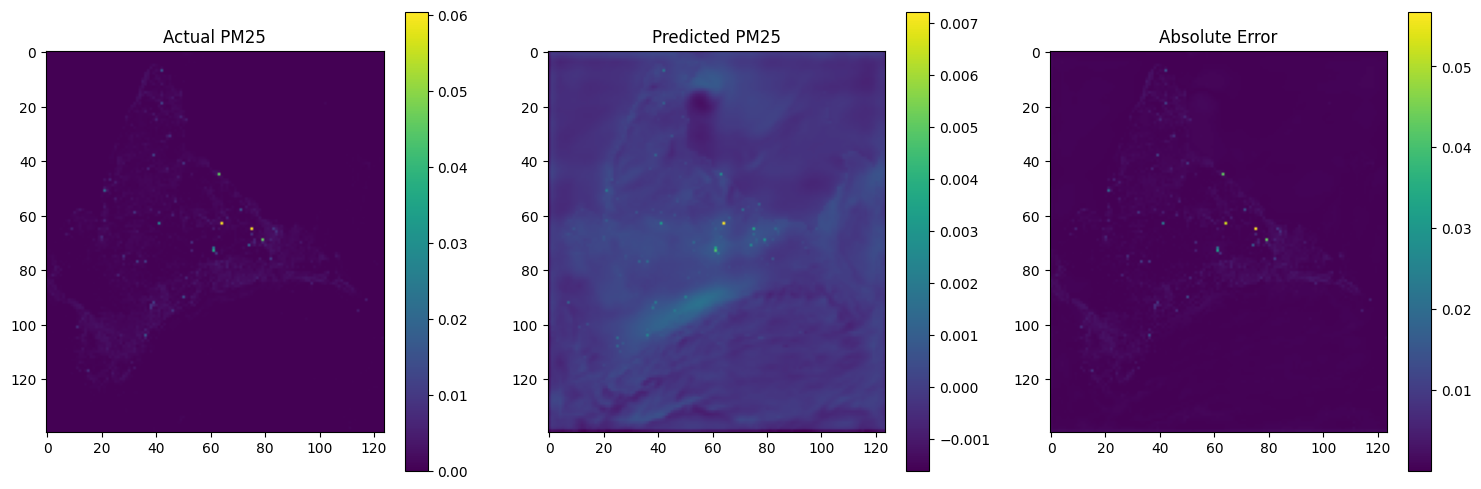

In [27]:
# ==========================================
# FINAL VISUALIZATION
# ==========================================

final_model.eval()

# ==========================================
# SAMPLE
# ==========================================

X_sample, y_sample = next(
    iter(val_loader)
)

X_sample = X_sample.to(device)

# ==========================================
# PREDICTION
# ==========================================

with torch.no_grad():
    
    pred_sample = final_model(
        X_sample
    )

pred_map = pred_sample[0].cpu().numpy()

true_map = y_sample[0].numpy()

# ==========================================
# ERROR MAP
# ==========================================

error_map = np.abs(
    true_map - pred_map
)

# ==========================================
# PLOTTING
# ==========================================

plt.figure(figsize=(15, 5))

# ACTUAL

plt.subplot(1, 3, 1)

plt.imshow(true_map)

plt.title("Actual PM25")

plt.colorbar()

# PREDICTED

plt.subplot(1, 3, 2)

plt.imshow(pred_map)

plt.title("Predicted PM25")

plt.colorbar()

# ERROR

plt.subplot(1, 3, 3)

plt.imshow(error_map)

plt.title("Absolute Error")

plt.colorbar()

plt.tight_layout()

plt.show()

In [28]:
# ==========================================
# FINAL FULL-DATASET EVALUATION
# ==========================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr

from skimage.metrics import (
    structural_similarity as ssim
)

# ==========================================
# EVALUATION MODE
# ==========================================

final_model.eval()

# ==========================================
# STORE PREDICTIONS
# ==========================================

all_preds = []

all_targets = []

with torch.no_grad():
    
    for X_batch, y_batch in val_loader:
        
        X_batch = X_batch.to(device)
        
        preds = final_model(X_batch)
        
        all_preds.append(
            preds.cpu().numpy()
        )
        
        all_targets.append(
            y_batch.numpy()
        )

# ==========================================
# CONCATENATE
# ==========================================

all_preds = np.concatenate(
    all_preds,
    axis=0
)

all_targets = np.concatenate(
    all_targets,
    axis=0
)

# ==========================================
# FLATTEN
# ==========================================

pred_flat = all_preds.flatten()

target_flat = all_targets.flatten()

# ==========================================
# RMSE
# ==========================================

final_rmse = np.sqrt(
    mean_squared_error(
        target_flat,
        pred_flat
    )
)

# ==========================================
# MAE
# ==========================================

final_mae = mean_absolute_error(
    target_flat,
    pred_flat
)

# ==========================================
# R2 SCORE
# ==========================================

final_r2 = r2_score(
    target_flat,
    pred_flat
)

# ==========================================
# PEARSON
# ==========================================

final_pearson, _ = pearsonr(
    target_flat,
    pred_flat
)

# ==========================================
# SSIM
# ==========================================

ssim_scores = []

for i in range(len(all_preds)):
    
    score = ssim(
        all_targets[i],
        all_preds[i],
        data_range=
        all_targets[i].max()
        -
        all_targets[i].min()
    )
    
    ssim_scores.append(score)

final_ssim = np.mean(
    ssim_scores
)

# ==========================================
# PRINT
# ==========================================

print("\n===== FINAL MODEL EVALUATION =====")

print(
    f"RMSE  : {final_rmse:.6f}"
)

print(
    f"MAE   : {final_mae:.6f}"
)

print(
    f"R²    : {final_r2:.6f}"
)

print(
    f"Pearson Correlation : {final_pearson:.6f}"
)

print(
    f"Mean SSIM : {final_ssim:.6f}"
)


===== FINAL MODEL EVALUATION =====
RMSE  : 0.001167
MAE   : 0.000562
R²    : -0.054766
Pearson Correlation : 0.382037
Mean SSIM : 0.552277


In [ ]:
# ==========================================
# SAVE BENGALURU PREDICTION FOR DASHBOARD
# ==========================================

import json
import os

# Get the latest predicted map (index -1)
pred_map = all_preds[-1]

# Channel 0 stats (PM2.5)
pm25_min = channel_mins[0]
pm25_max = channel_maxs[0]

# Denormalize (multiply by 1e9 to convert kg/m³ to µg/m³)
pred_map_denorm = pred_map * (pm25_max - pm25_min) + pm25_min
pred_map_ug = pred_map_denorm * 1e9

# Find grid coordinates for Bengaluru
lat_long_paths = [
    "/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/raw/lat_long.npy",
    "lat_long.npy",
    os.path.join(base_path, "lat_long.npy")
]

lat_long = None
for p in lat_long_paths:
    if os.path.exists(p):
        lat_long = np.load(p)
        break

if lat_long is None:
    # Fallback to a reasonable center index in case lat_long is missing
    bglr_r, bglr_c = 25, 45
    print("Warning: lat_long.npy not found, using default index")
else:
    lats = lat_long[0]
    lons = lat_long[1]
    dist = (lats - 12.97)**2 + (lons - 77.59)**2
    bglr_idx = np.argmin(dist)
    bglr_r, bglr_c = np.unravel_index(bglr_idx, lats.shape)
    print(f"Bengaluru index: ({bglr_r}, {bglr_c})")

pm25_blr = pred_map_ug[bglr_r, bglr_c]

def get_category(pm25):
    if pm25 <= 30:
        return "Good"
    elif pm25 <= 60:
        return "Moderate"
    elif pm25 <= 90:
        return "Sensitive Groups"
    elif pm25 <= 120:
        return "Unhealthy"
    else:
        return "Hazardous"

output_data = {
    "location": "Bengaluru",
    "prediction_window": "10-hour",
    "pm25": int(round(pm25_blr)),
    "category": get_category(pm25_blr)
}

# Paths to try saving the file
save_paths = [
    r"D:\projects\esprit-smartaithon\frontend\public\model_output.json",
    "model_output.json"
]

saved = False
for path in save_paths:
    dir_name = os.path.dirname(path)
    if not dir_name or os.path.exists(dir_name):
        with open(path, "w") as f:
            json.dump(output_data, f, indent=2)
        print(f"Saved prediction output to {path}")
        saved = True
        break

if not saved:
    with open("model_output.json", "w") as f:
        json.dump(output_data, f, indent=2)
    print("Saved prediction output to model_output.json in current directory")


In [ ]:

import os
import json
import torch
import numpy as np
import shutil

export_dir = "/kaggle/working/atmoai_deployment"
os.makedirs(export_dir, exist_ok=True)

# 1. Save Model Weights
model_path = os.path.join(export_dir, "atmoai_pm25_model.pth")
torch.save(model.state_dict(), model_path)
print("Model saved: YES")

# 2. Save Architecture Metadata
config_path = os.path.join(export_dir, "atmoai_model_config.json")
config = {
    "architecture": "ResidualFNOCNNHybrid",
    "input_channels": 12,
    "variables": variables,
    "sequence_length": 12,
    "grid_height": 140,
    "grid_width": 124,
    "target_channel": 0,
    "target_variable": "PM25",
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print("Architecture metadata saved: YES")

# 3. Save Normalization Artifact
prep_path = os.path.join(export_dir, "atmoai_preprocessing.json")
preprocessing = {
    "variables": variables,
    "target_channel": 0,
    "target_variable": "PM25",
    "channel_mins": [float(x) for x in channel_mins],
    "channel_maxs": [float(x) for x in channel_maxs]
}
with open(prep_path, "w") as f:
    json.dump(preprocessing, f, indent=2)
print("Preprocessing saved: YES")

# 4. Copy Geographic Grid
lat_long_src = None
for p in lat_long_paths:
    if os.path.exists(p):
        lat_long_src = p
        break

if lat_long_src:
    lat_long_dst = os.path.join(export_dir, "lat_long.npy")
    shutil.copy(lat_long_src, lat_long_dst)
    lat_long = np.load(lat_long_dst)
    lats = lat_long[0]
    lons = lat_long[1]
    print("Geographic grid saved: YES")
else:
    print("Geographic grid saved: FAIL - lat_long.npy not found")
    lats = np.zeros((140, 124))
    lons = np.zeros((140, 124))

# 5. Validation Prediction
model.eval()
with torch.no_grad():
    val_sample = torch.tensor(X_val[0:1], dtype=torch.float32).to(device)
    pred_norm = model(val_sample)
    pred_norm = pred_norm.cpu().numpy()[0] # Shape: (140, 124)

val_pred_path_npy = os.path.join(export_dir, "validation_prediction.npy")
np.save(val_pred_path_npy, pred_norm)

pm25_min = channel_mins[0]
pm25_max = channel_maxs[0]
pred_denorm = pred_norm * (pm25_max - pm25_min + 1e-8) + pm25_min
pred_ug = pred_denorm * 1e9

records = []
for i in range(pred_ug.shape[0]):
    for j in range(pred_ug.shape[1]):
        val = float(pred_ug[i, j])
        if val <= 30: cat = "Good"
        elif val <= 60: cat = "Moderate"
        elif val <= 90: cat = "Sensitive Groups"
        elif val <= 120: cat = "Unhealthy"
        else: cat = "Hazardous"
        
        records.append({
            "lat": float(lats[i, j]),
            "lng": float(lons[i, j]),
            "predicted_pm25": val,
            "category": cat
        })

val_pred_path_json = os.path.join(export_dir, "validation_prediction.json")
with open(val_pred_path_json, "w") as f:
    json.dump(records, f)

print("Validation prediction generated: YES")
print(f"Grid shape: {pred_denorm.shape}")
print(f"Prediction min: {pred_ug.min():.4f}")
print(f"Prediction max: {pred_ug.max():.4f}")
print(f"Prediction mean: {pred_ug.mean():.4f}")

# 10. CRITICAL VALIDATION (Reload Test)
reloaded_model = ResidualFNOCNNHybrid().to(device)
reloaded_model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
reloaded_model.eval()

with torch.no_grad():
    reloaded_pred = reloaded_model(val_sample).cpu().numpy()[0]

max_diff = np.max(np.abs(pred_norm - reloaded_pred))
mean_diff = np.mean(np.abs(pred_norm - reloaded_pred))

print(f"RELOAD TEST MAX ABS DIFFERENCE: {max_diff}")
print(f"RELOAD TEST MEAN ABS DIFFERENCE: {mean_diff}")
